In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/raw/customer_churn.csv')

print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()
display(df.head())

Dimensions : 10000 lignes × 32 colonnes



,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [4]:
print("=== Types de données ===")
print(df.dtypes)
print()

missing = df.isnull().sum()
print("=== Valeurs manquantes ===")
print("Aucune valeur manquante !" if missing.sum() == 0 else missing[missing > 0])

print()
print("=== Statistiques descriptives ===")
display(df.describe())

=== Types de données ===
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score              

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


Non-churn (0) : 8979 clients  (89.8%)
Churn     (1) : 1021 clients  (10.2%)


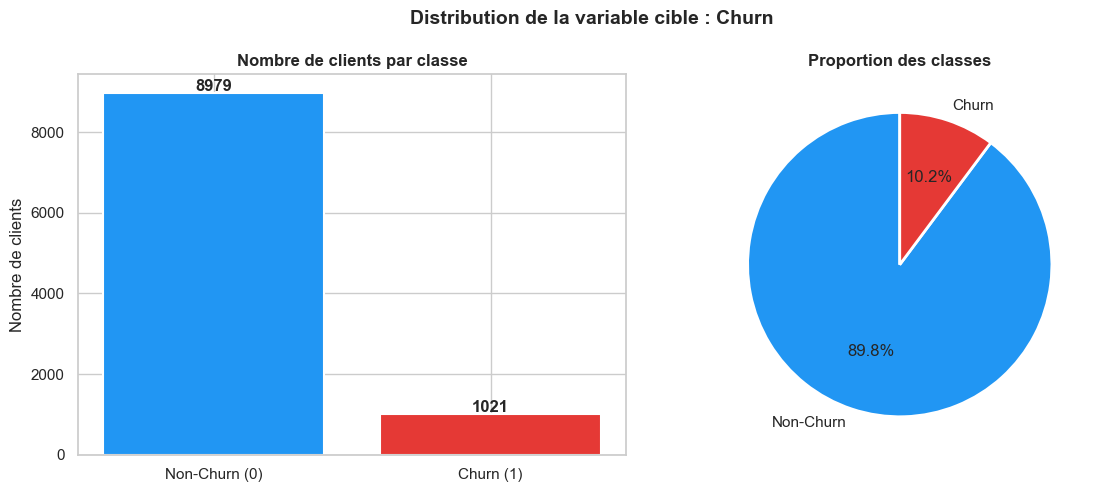

In [5]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print(f"Non-churn (0) : {churn_counts[0]} clients  ({churn_pct[0]:.1f}%)")
print(f"Churn     (1) : {churn_counts[1]} clients  ({churn_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts,
            color=['#2196F3', '#E53935'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Nombre de clients par classe', fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=['Non-Churn', 'Churn'],
            colors=['#2196F3', '#E53935'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.suptitle('Distribution de la variable cible : Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Variables numériques (19) : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']


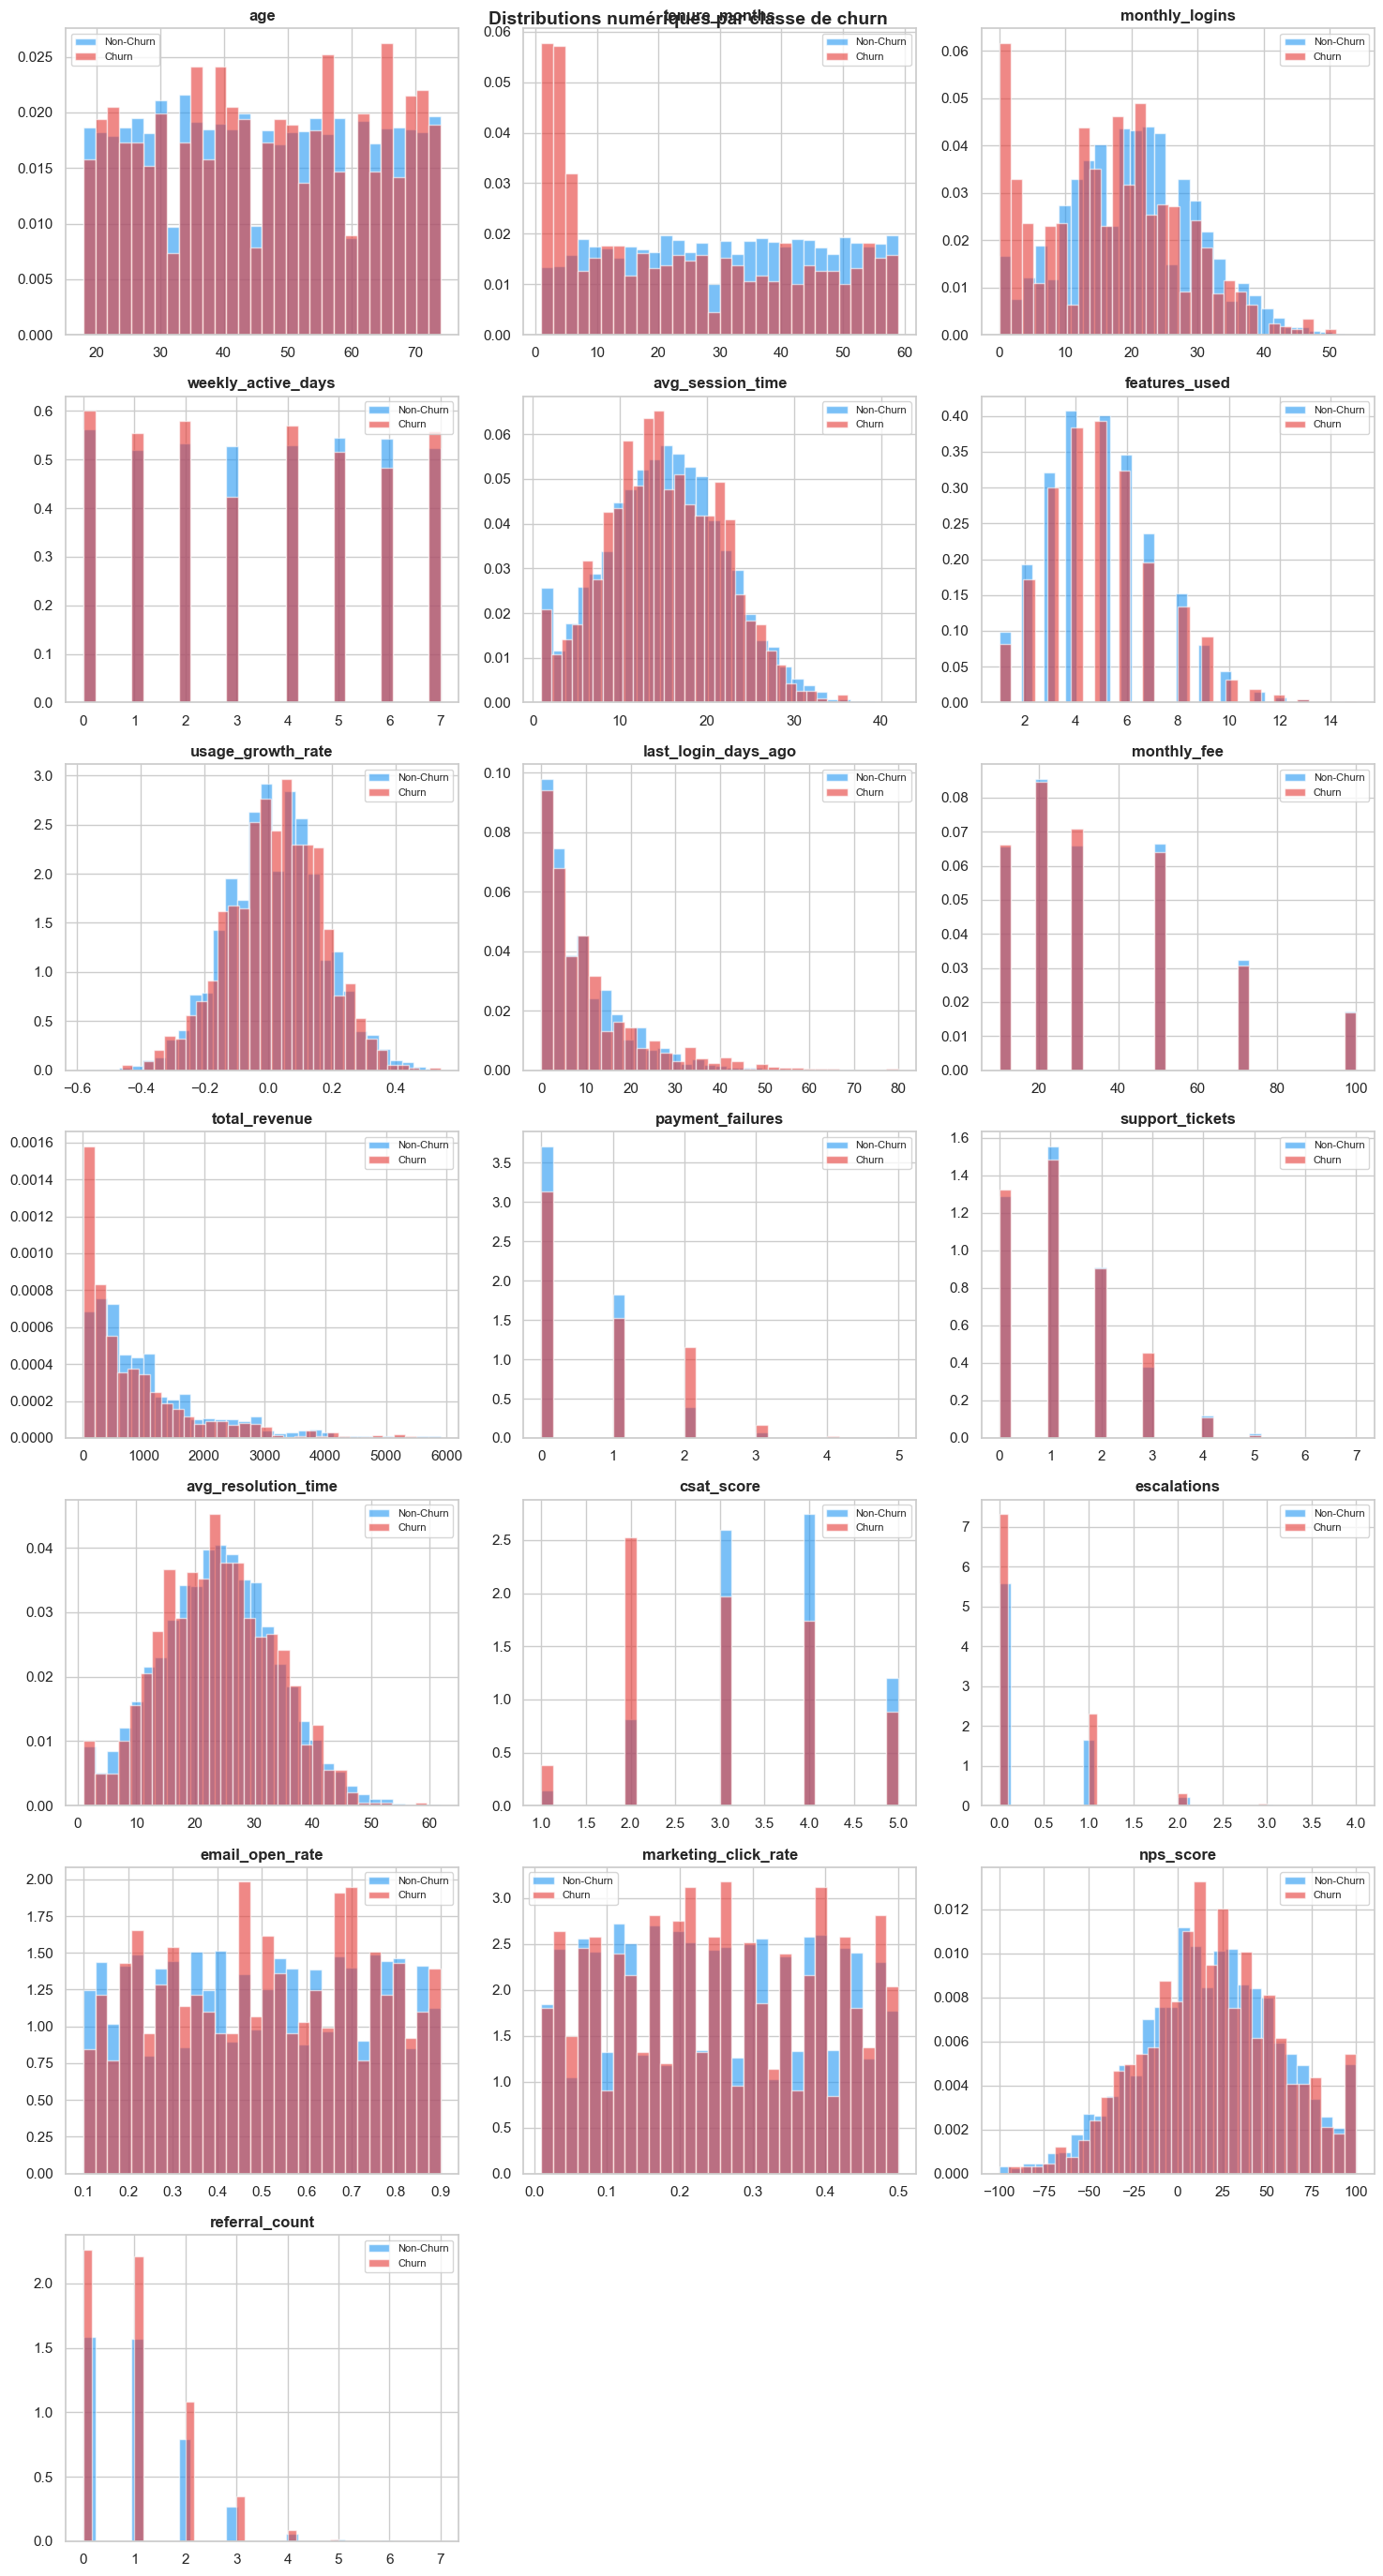

In [6]:
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c != 'churn']
print(f"Variables numériques ({len(num_cols)}) : {num_cols}")

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[df['churn']==0][col].hist(ax=axes[i], alpha=0.6, color='#2196F3',
                                  label='Non-Churn', bins=30, density=True)
    df[df['churn']==1][col].hist(ax=axes[i], alpha=0.6, color='#E53935',
                                  label='Churn', bins=30, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions numériques par classe de churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\wahba\AppData\Local\Temp\ipykernel_27688\2326880598.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Variables catégorielles (12) : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


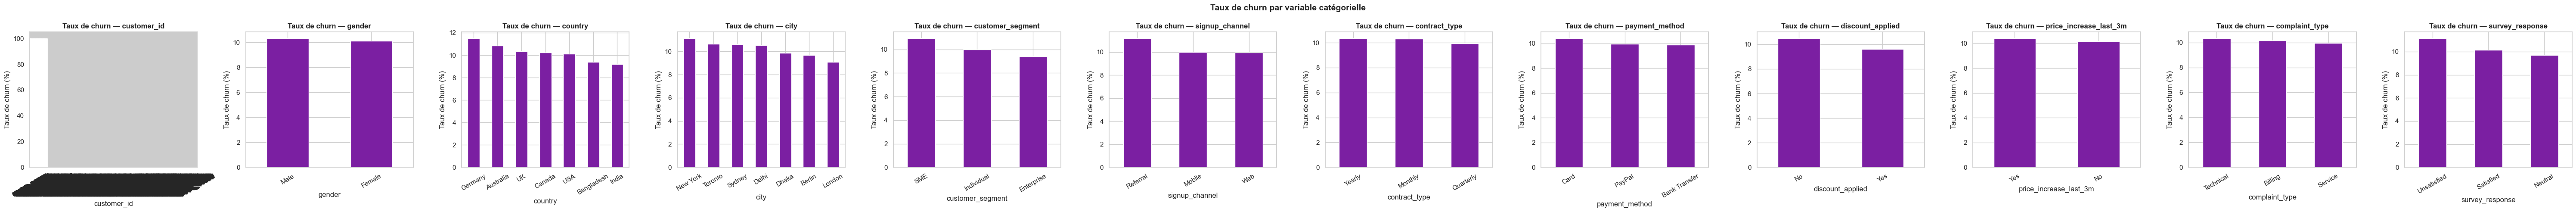

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables catégorielles ({len(cat_cols)}) : {cat_cols}")

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]
    for i, col in enumerate(cat_cols):
        churn_rate = df.groupby(col)['churn'].mean() * 100
        churn_rate.sort_values(ascending=False).plot(
            kind='bar', ax=axes[i], color='#7B1FA2', edgecolor='white')
        axes[i].set_title(f'Taux de churn — {col}', fontweight='bold')
        axes[i].set_ylabel('Taux de churn (%)')
        axes[i].tick_params(axis='x', rotation=30)
    plt.suptitle('Taux de churn par variable catégorielle', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

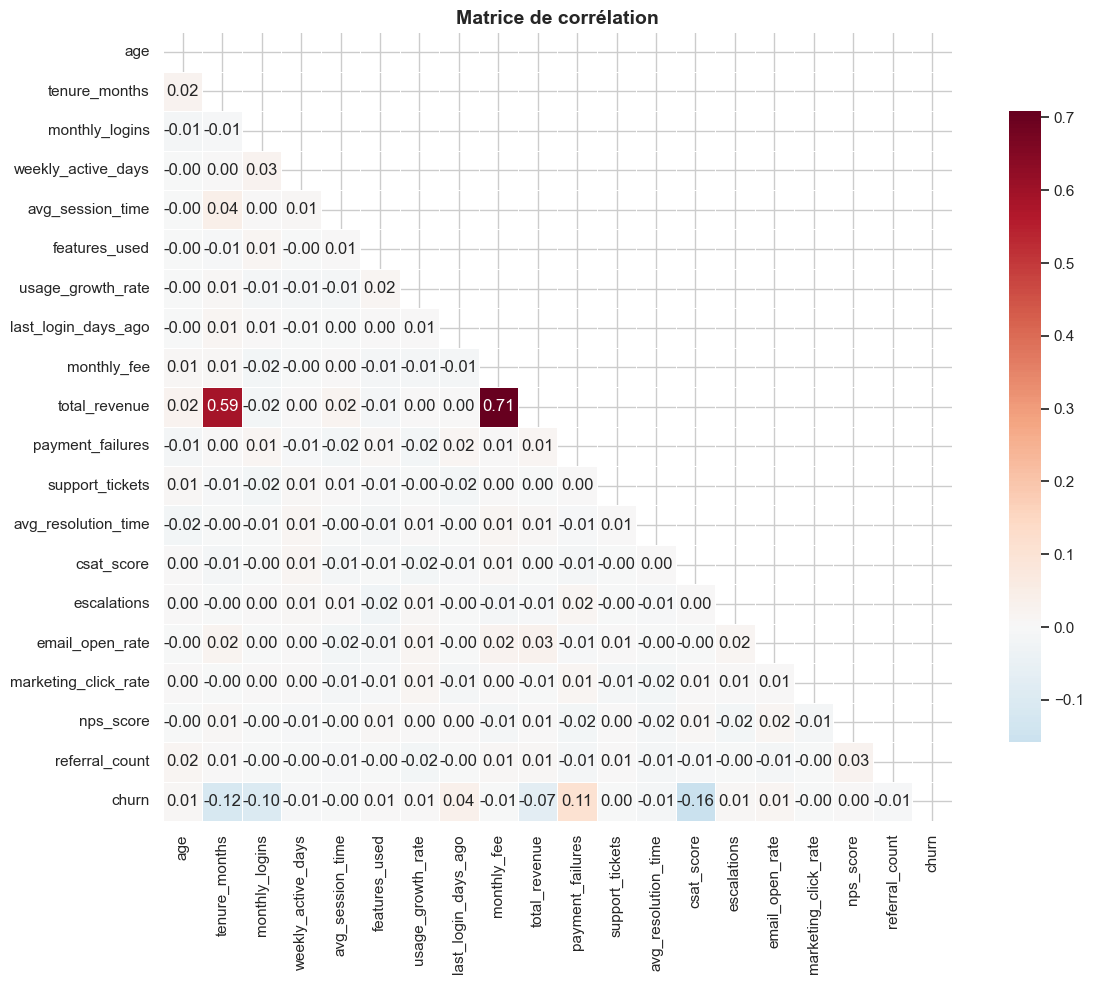

=== Top corrélations avec le churn ===
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924


In [8]:
corr_matrix = df[num_cols + ['churn']].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Top corrélations avec le churn ===")
print(corr_matrix['churn'].drop('churn').sort_values(ascending=False).to_string())

In [9]:
# ============================================================
# CELLULE 7 — Nettoyage et feature engineering
# ============================================================

df_clean = df.copy()

# 1. Suppression des colonnes inutiles pour la modélisation
#    customer_id : identifiant unique, pas prédictif
#    city/country : trop de modalités, peu de signal métier ici
cols_to_drop = ['customer_id', 'city', 'country']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Colonnes supprimées : {cols_to_drop}")

# 2. Remplissage des valeurs manquantes de complaint_type
#    Logique métier : pas de complaint_type = pas de plainte
df_clean['complaint_type'] = df_clean['complaint_type'].fillna('No_complaint')
print(f"Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

# 3. Feature engineering — 3 nouvelles variables métier utiles
#    Ratio engagement : logins normalisés par ancienneté
df_clean['login_per_month'] = df_clean['monthly_logins'] / (df_clean['tenure_months'] + 1)

#    Score de risque paiement : cumul des échecs
df_clean['payment_risk'] = df_clean['payment_failures'] * df_clean['monthly_fee']

#    Engagement récent inversé : plus last_login_days_ago est grand, moins c'est bon
df_clean['recency_risk'] = df_clean['last_login_days_ago'] / (df_clean['avg_session_time'] + 1)

print("\nNouvelles features créées : login_per_month, payment_risk, recency_risk")
print(f"\nDimensions finales : {df_clean.shape}")
display(df_clean.head(3))

Colonnes supprimées : ['customer_id', 'city', 'country']
Valeurs manquantes restantes : 0

Nouvelles features créées : login_per_month, payment_risk, recency_risk

Dimensions finales : (10000, 32)


,gender,age,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,features_used,...,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn,login_per_month,payment_risk,recency_risk
0,Male,68,SME,22,Web,Monthly,26,7,11.762372,5,...,0,0.71,0.40,27,Satisfied,1,0,1.130435,30,0.548487
1,Female,57,Individual,9,Mobile,Monthly,7,5,26.846390,1,...,0,0.78,0.33,-19,Neutral,2,1,0.700000,30,0.071823
2,Male,24,SME,58,Web,Yearly,19,5,23.380065,6,...,0,0.35,0.49,80,Neutral,1,0,0.322034,40,0.943394


In [10]:
# ============================================================
# CELLULE 8 — Encodage des variables catégorielles
# ============================================================

# Variables catégorielles à encoder
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Variables catégorielles à encoder : {cat_cols}")

# On utilise pd.get_dummies (One-Hot Encoding)
# drop_first=True évite la multicolinéarité (dummy trap)
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f"\nDimensions après encodage : {df_encoded.shape}")
print(f"Nouvelles colonnes créées : {df_encoded.shape[1] - df_clean.shape[1] + len(cat_cols)}")

# Vérification : plus aucune colonne object
print(f"Colonnes object restantes : {df_encoded.select_dtypes(include='object').shape[1]}")
display(df_encoded.head(3))

Variables catégorielles à encoder : ['gender', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

Dimensions après encodage : (10000, 39)
Nouvelles colonnes créées : 16
Colonnes object restantes : 0


C:\Users\wahba\AppData\Local\Temp\ipykernel_27688\331360577.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,contract_type_Yearly,payment_method_Card,payment_method_PayPal,discount_applied_Yes,price_increase_last_3m_Yes,complaint_type_No_complaint,complaint_type_Service,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied
0,68,22,26,7,11.762372,5,0.06,7,30,660,...,False,False,True,True,False,False,True,False,True,False
1,57,9,7,5,26.846390,1,-0.28,2,30,270,...,False,True,False,False,True,False,False,False,False,False
2,24,58,19,5,23.380065,6,0.13,23,20,1160,...,True,True,False,False,False,False,True,False,False,False


In [11]:
# ============================================================
# CELLULE 9 — Split train/test + normalisation
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Séparation features / cible
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

print(f"Features (X) : {X.shape}")
print(f"Cible    (y) : {y.shape}")
print(f"Taux de churn : {y.mean()*100:.1f}%")

# Split stratifié — IMPORTANT avec un dataset déséquilibré
# stratify=y garantit la même proportion de churn dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproductibilité
    stratify=y            # préserve la proportion de churn
)

print(f"\nTrain : {X_train.shape[0]} lignes | churn : {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]}  lignes | churn : {y_test.mean()*100:.1f}%")

# Normalisation — StandardScaler : moyenne=0, écart-type=1
# IMPORTANT : on fit UNIQUEMENT sur le train, puis on transforme train ET test
# => évite le data leakage (contamination du test par le train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_scaled  = scaler.transform(X_test)         # transform seulement sur test

# Conversion en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("\nNormalisation appliquée (StandardScaler)")
print(f"Moyenne train (exemple tenure_months) : {X_train_scaled['tenure_months'].mean():.4f}")
print(f"Std    train  (exemple tenure_months) : {X_train_scaled['tenure_months'].std():.4f}")

# Sauvegarde des données préparées et du scaler
os.makedirs('../data/processed', exist_ok=True)
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv',        index=False)
y_test.to_csv('../data/processed/y_test.csv',          index=False)
joblib.dump(scaler, '../data/processed/scaler.pkl')

print("\nFichiers sauvegardés dans data/processed/ :")
print("  X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl")

Features (X) : (10000, 38)
Cible    (y) : (10000,)
Taux de churn : 10.2%

Train : 8000 lignes | churn : 10.2%
Test  : 2000  lignes | churn : 10.2%

Normalisation appliquée (StandardScaler)
Moyenne train (exemple tenure_months) : 0.0000
Std    train  (exemple tenure_months) : 1.0001

Fichiers sauvegardés dans data/processed/ :
  X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl
